# Model Training & Evaluation

## Import Library & Setup Path

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Setup Direktori ─────────────────────────────────────────────────────────
current_dir = Path(os.getcwd())
BASE_DIR = current_dir.parent if current_dir.name == 'notebooks' else current_dir
DATA_PATH = BASE_DIR / 'data' / 'processed' / 'combined_clean.csv'

MODEL_DIR = BASE_DIR / 'model' / 'saved_model'
MODEL_PATH = MODEL_DIR / 'skin_model.keras'
META_PATH = MODEL_DIR / 'model_metadata.json'

print("✅ TensorFlow Version:", tf.__version__)
print("📁 Model Directory:", MODEL_DIR)

✅ TensorFlow Version: 2.9.0
📁 Model Directory: c:\G\Bootcamp\PORTOFOLIO\DermaScan\model\saved_model


## Load Metadata & Reproduksi Test Set

In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Setup Direktori ─────────────────────────────────────────────────────────
current_dir = Path(os.getcwd())
BASE_DIR = current_dir.parent if current_dir.name == 'notebooks' else current_dir
DATA_PATH = BASE_DIR / 'data' / 'processed' / 'combined_clean.csv'

MODEL_DIR = BASE_DIR / 'model' / 'saved_model'
MODEL_PATH = MODEL_DIR / 'skin_model.keras'
META_PATH = MODEL_DIR / 'model_metadata.json'

print("✅ TensorFlow Version:", tf.__version__)
print("📁 Model Directory:", MODEL_DIR)

✅ TensorFlow Version: 2.9.0
📁 Model Directory: c:\G\Bootcamp\PORTOFOLIO\DermaScan\model\saved_model


## Load Metadata & Reproduksi Test Set

In [3]:
# 1. Load Metadata Model
with open(META_PATH, 'r') as f:
    metadata = json.load(f)

IMG_SIZE = tuple(metadata['img_size'])
BATCH_SIZE = 32
CLASS_NAMES_LIST = metadata['class_names']
print(f"✅ Metadata dimuat. Mendeteksi {metadata['num_classes']} kelas dari otak AI.")

# 2. Reproduksi Test Set
df = pd.read_csv(DATA_PATH)

# --- TAMBAHAN KODE UNTUK MEMPERBAIKI FOLDER YANG BERUBAH NAMA ---
# Mengganti teks 'Skin Health Analyzer' menjadi 'DermaScan' di dalam data
df['image_path'] = df['image_path'].str.replace('Skin Health Analyzer', 'DermaScan')
# ----------------------------------------------------------------

_, temp_df = train_test_split(df, test_size=0.3, stratify=df["dx"], random_state=42)
_, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["dx"], random_state=42)

print(f"📊 Menyiapkan {len(test_df)} gambar Ujian (Test Set) untuk dievaluasi.")

# 3. Test Data Generator (Tanpa Augmentasi)
test_gen = ImageDataGenerator()
test_flow = test_gen.flow_from_dataframe(
    test_df, x_col="image_path", y_col="dx", 
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, 
    class_mode="categorical", shuffle=False
)

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\G\\Bootcamp\\PORTOFOLIO\\DermaScan\\model\\saved_model\\model_metadata.json'

## Load Model & Laporan Klasifikasi

In [ ]:
# Muat model yang sudah jadi
print("⏳ Memuat model CNN ke memori...")
model = tf.keras.models.load_model(str(MODEL_PATH))
print("✅ Model berhasil dimuat!")

# Lakukan Prediksi Masal pada Test Set
print("\n🔄 AI sedang mengerjakan ujian pada Test Set...")
test_flow.reset()
predictions = model.predict(test_flow)
y_pred = np.argmax(predictions, axis=1)
y_true = test_flow.classes

# Tampilkan Laporan Evaluasi Lengkap
print("\n" + "═"*60)
print("📊 CLASSIFICATION REPORT")
print("═"*60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES_LIST, zero_division=0))

⏳ Memuat model CNN ke memori...
✅ Model berhasil dimuat!

🔄 AI sedang mengerjakan ujian pada Test Set...
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 400ms/step

════════════════════════════════════════════════════════════
📊 CLASSIFICATION REPORT
════════════════════════════════════════════════════════════
                   precision    recall  f1-score   support

   Nail_psoriasis       0.95      0.96      0.96       378
          SJS-TEN       0.98      0.83      0.90       475
         Vitiligo       0.88      0.91      0.89       303
             acne       0.86      1.00      0.92       172
            akiec       0.42      0.41      0.41        49
              bcc       0.47      0.58      0.52        77
              bkl       0.46      0.59      0.52       165
      combination       0.22      0.22      0.22         9
               df       0.18      0.65      0.28        17
              dry       0.36      0.36      0.36        39
hyperpigmentation       0.80      0.97      0.88       1

## Visualisasi Confusion Matrix

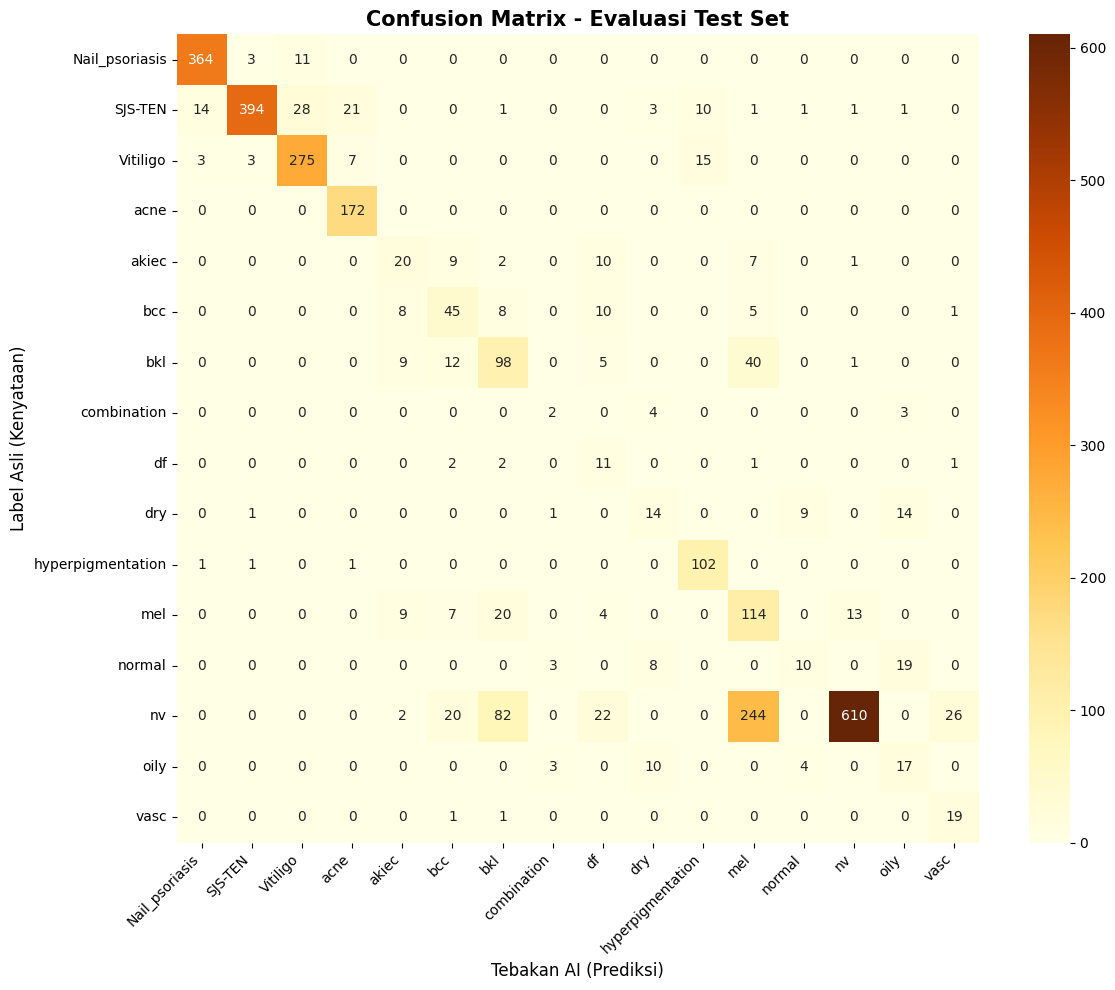

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', 
            xticklabels=CLASS_NAMES_LIST, yticklabels=CLASS_NAMES_LIST)
plt.title('Confusion Matrix - Evaluasi Test Set', fontsize=15, fontweight='bold')
plt.ylabel('Label Asli (Kenyataan)', fontsize=12)
plt.xlabel('Tebakan AI (Prediksi)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Simulasi Uji Prediksi 1 Gambar (Inference)

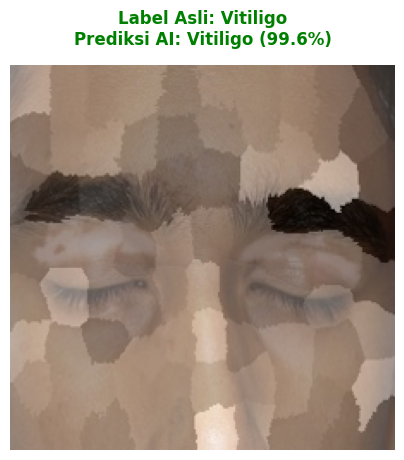

In [ ]:
# Ambil 1 gambar acak dari Test Set
random_idx = random.randint(0, len(test_df) - 1)
sample_img_path = test_df.iloc[random_idx]['image_path']
true_label = test_df.iloc[random_idx]['dx']
true_display_name = metadata['class_display_names'].get(true_label, true_label)

# Preprocessing Gambar (Mirip seperti fungsi predict.py)
img = Image.open(sample_img_path).convert('RGB').resize(IMG_SIZE)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Prediksi AI
pred_probs = model.predict(img_array, verbose=0)[0]
pred_idx = np.argmax(pred_probs)
pred_label = CLASS_NAMES_LIST[pred_idx]
pred_display_name = metadata['class_display_names'].get(pred_label, pred_label)
confidence = pred_probs[pred_idx] * 100

# Pewarnaan teks (Hijau jika tebakan AI benar, Merah jika salah)
text_color = 'green' if true_label == pred_label else 'red'

# Tampilkan Hasil Visual
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
plt.title(f"Label Asli: {true_display_name}\nPrediksi AI: {pred_display_name} ({confidence:.1f}%)", 
          color=text_color, fontweight='bold', pad=15)
plt.show()